# Health-to-Vehicle Insurance Cross-Sell Propensity Modeling
**Dataset:** Health Insurance Cross Sell Prediction (Kaggle Dataset).
**Dimensi Data:** 381.109 nasabah asuransi kesehatan dengan variabel demografis, kepemilikan polis, dan respons minat asuransi kendaraan (`Response`).

Notebook ini membangun sistem penargetan pemasaran berbasis probabilitas kecenderungan (*Propensity Scoring / Uplift Targeting*). Tujuannya adalah mengidentifikasi nasabah asuransi kesehatan yang berpeluang paling tinggi untuk membeli produk asuransi kendaraan, sehingga menekan biaya *telemarketing campaign* dan memaksimalkan *conversion rate*.

### Arsitektur Pipeline Analisis:
1. **Data Ingestion & Integrity Check**: Pemuatan 381.109 baris data nasabah, pemeriksaan missing values, dan verifikasi duplikasi ID.
2. **Cross-Sell Behavioral EDA**: Analisis kecenderungan respons berdasarkan kepemilikan asuransi sebelumnya (`Previously_Insured`), riwayat kerusakan kendaraan (`Vehicle_Damage`), dan usia kendaraan (`Vehicle_Age`).
3. **Zero-Leakage Preprocessing & Pipeline**: Holdout Split terisolasi (80:20), One-Hot/Ordinal encoding pada fitur kategorikal, dan standardisasi numerik.
4. **Propensity Model Training**: Perbandingan Linear Baseline (Logistic Regression), Random Forest, dan Gradient Boosting (LightGBM & XGBoost).
5. **Marketing Campaign Evaluation**: Evaluasi metrik ROC-AUC, Cumulative Gains Chart, Lift Curve per Desil Pemasaran, dan visualisasi 300 DPI ke `images/`.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix
)
import lightgbm as lgb

os.makedirs('images', exist_ok=True)
os.makedirs('data', exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.titlesize': 15,
    'figure.figsize': (12, 6)
})

print("Konfigurasi pustaka dan direktori gambar visualisasi berhasil diinisialisasi.")

Konfigurasi pustaka dan direktori gambar visualisasi berhasil diinisialisasi.


In [2]:
df = pd.read_csv('data/train.csv')

print(f"Dimensi data cross-sell: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print("\nDistribusi Target Respons Minat (Response):")
print(df['Response'].value_counts())
print(f"Tingkat Konversi Alami (Natural Conversion Rate): {df['Response'].mean() * 100:.2f}%")
df.head()

Dimensi data cross-sell: 381,109 baris x 12 kolom

Distribusi Target Respons Minat (Response):
Response
0    334399
1     46710
Name: count, dtype: int64
Tingkat Konversi Alami (Natural Conversion Rate): 12.26%


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5008\2954121034.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resp_prev, x='Previously_Insured', y='Response', palette='Blues_r', ax=axes[0, 0])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5008\2954121034.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Belum Punya Asuransi Kendaraan (0)', 'Sudah Punya Asuransi (1)'])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5008\2954121034.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resp_dmg, x='Vehicle_Damage', y='Response', palette='Reds_r', ax=axes[0, 1])


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5008\2954121034.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resp_vage, x='Vehicle_Age', y='Response', palette='Greens_r', ax=axes[1, 0])


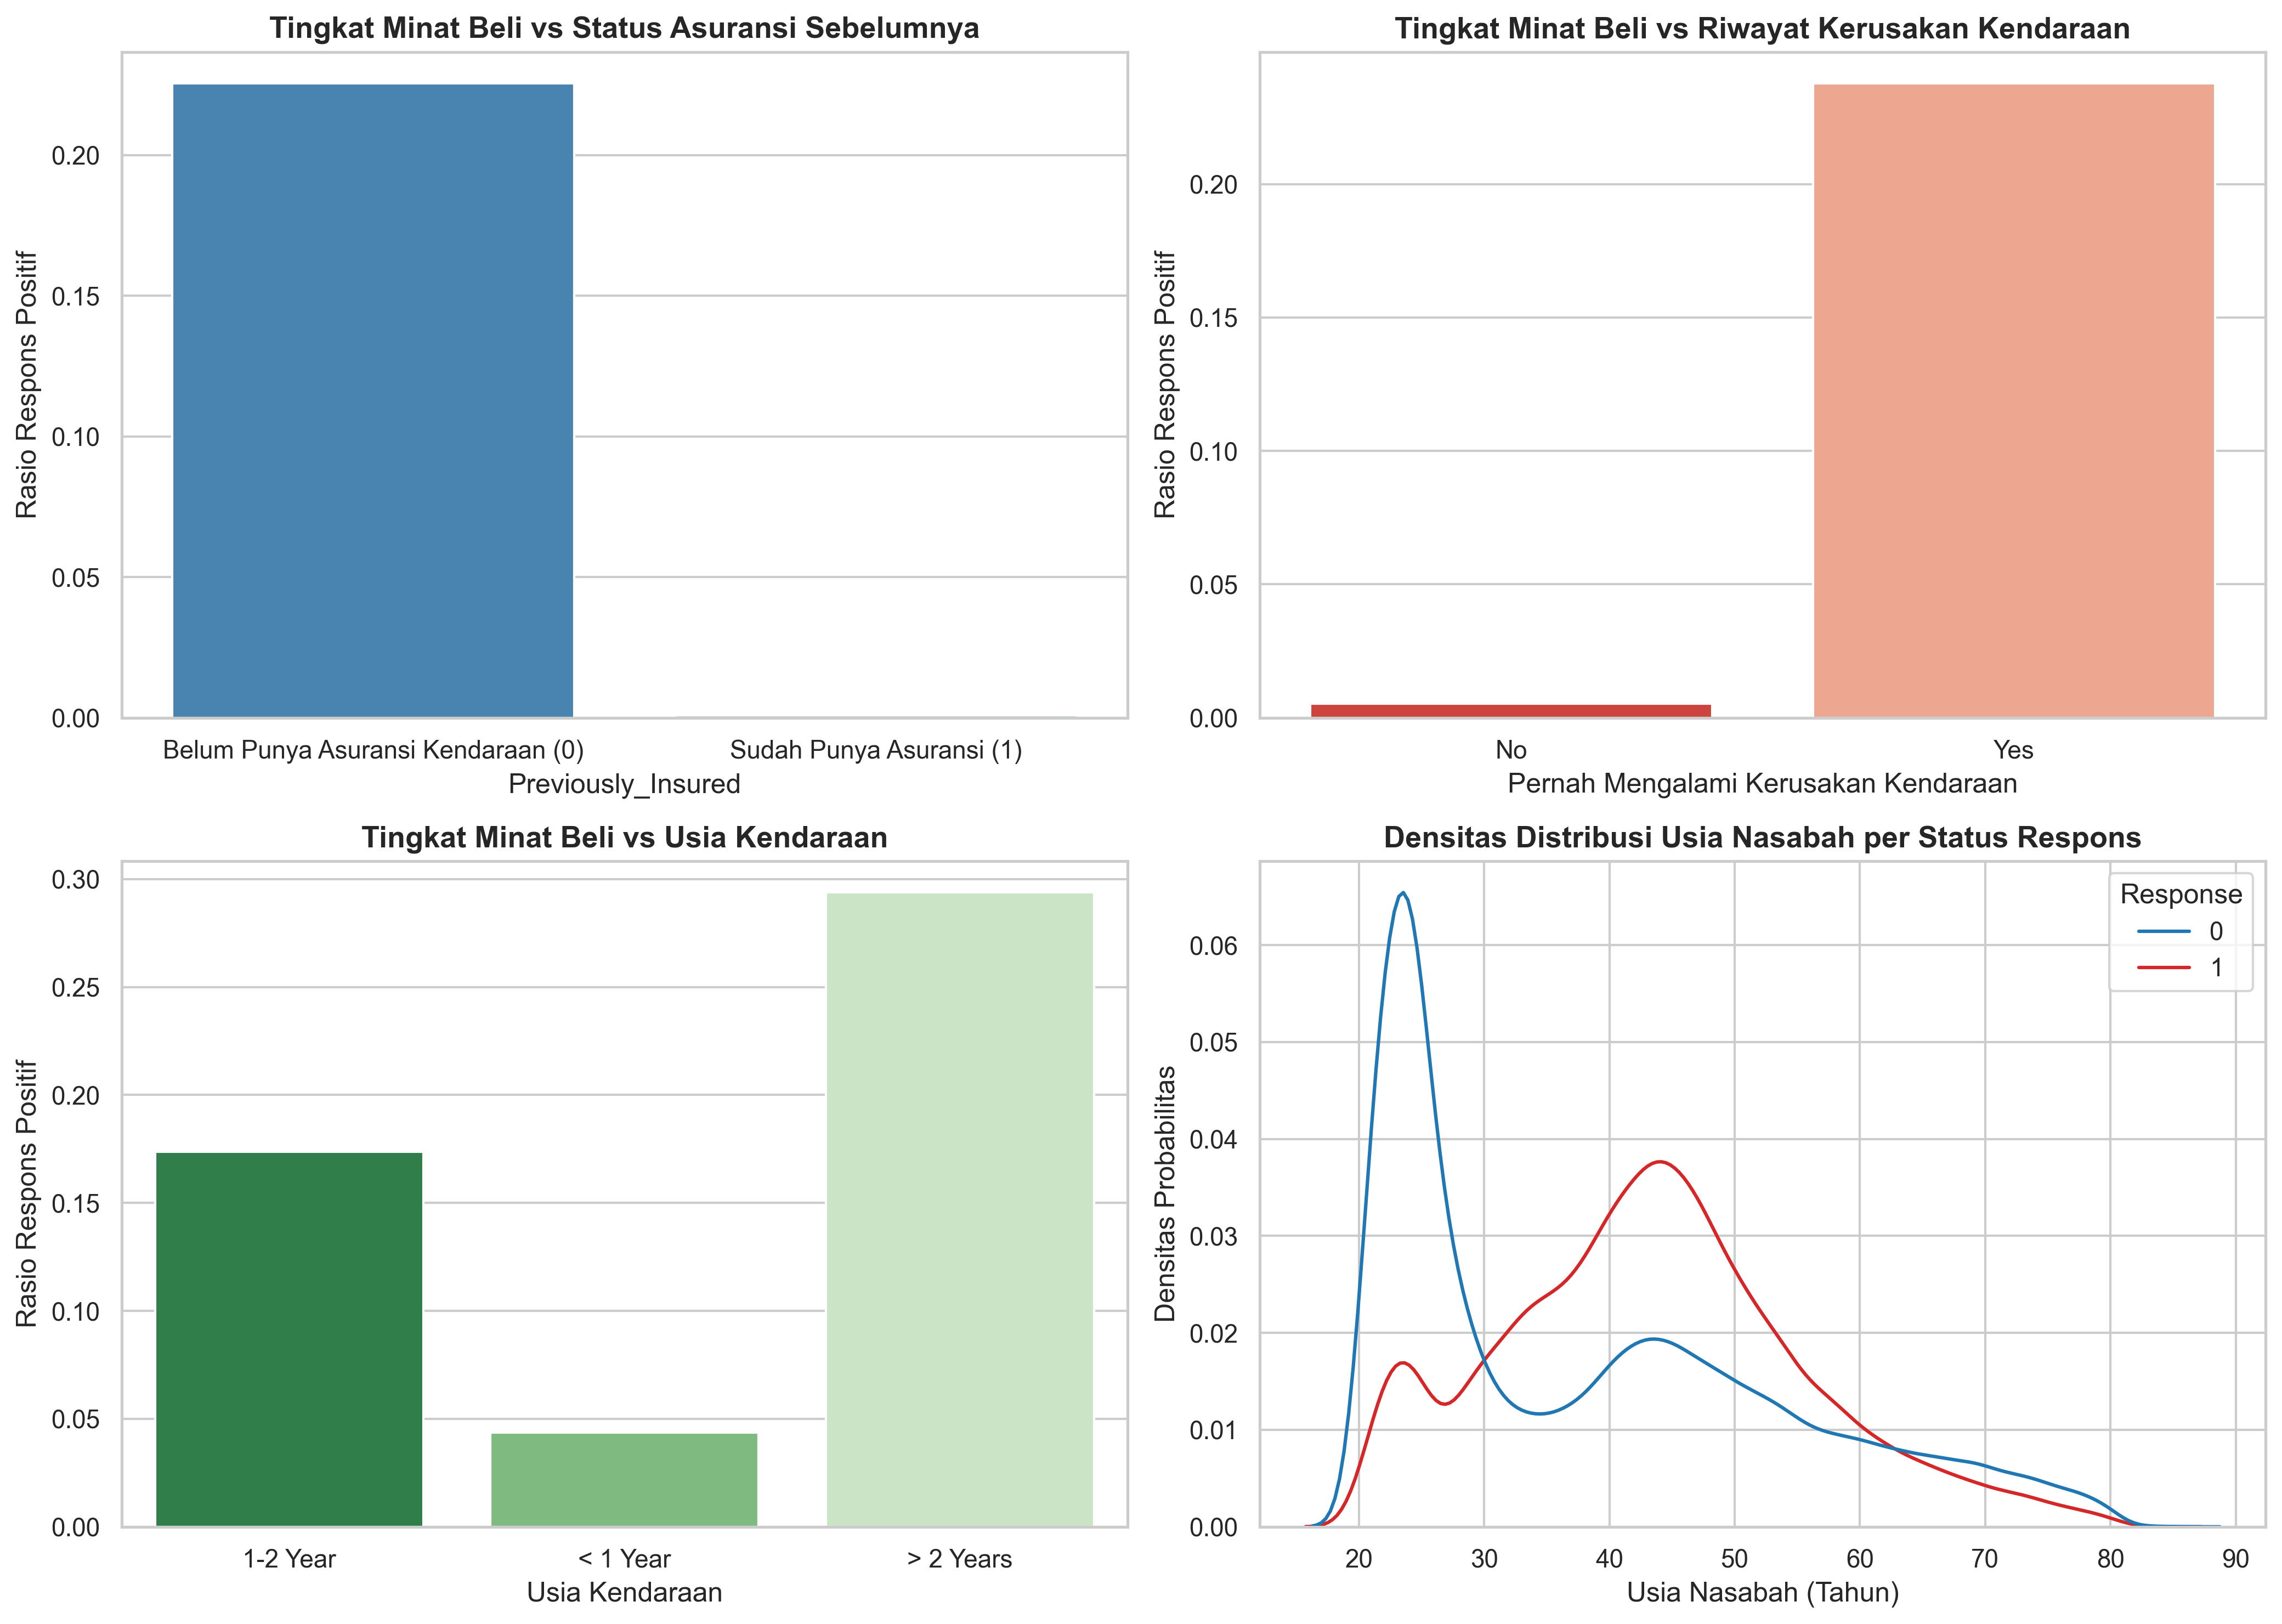

Visualisasi perilaku cross-sell berhasil diekspor ke images/cross_sell_eda.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Tingkat Respons vs Status Kepemilikan Asuransi Sebelumnya (Previously_Insured)
resp_prev = df.groupby('Previously_Insured')['Response'].mean().reset_index()
sns.barplot(data=resp_prev, x='Previously_Insured', y='Response', palette='Blues_r', ax=axes[0, 0])
axes[0, 0].set_title('Tingkat Minat Beli vs Status Asuransi Sebelumnya', fontweight='bold')
axes[0, 0].set_xticklabels(['Belum Punya Asuransi Kendaraan (0)', 'Sudah Punya Asuransi (1)'])
axes[0, 0].set_ylabel('Rasio Respons Positif')

# 2. Tingkat Respons vs Riwayat Kerusakan Kendaraan (Vehicle_Damage)
resp_dmg = df.groupby('Vehicle_Damage')['Response'].mean().reset_index()
sns.barplot(data=resp_dmg, x='Vehicle_Damage', y='Response', palette='Reds_r', ax=axes[0, 1])
axes[0, 1].set_title('Tingkat Minat Beli vs Riwayat Kerusakan Kendaraan', fontweight='bold')
axes[0, 1].set_xlabel('Pernah Mengalami Kerusakan Kendaraan')
axes[0, 1].set_ylabel('Rasio Respons Positif')

# 3. Tingkat Respons Berdasarkan Usia Kendaraan (Vehicle_Age)
resp_vage = df.groupby('Vehicle_Age')['Response'].mean().reset_index()
sns.barplot(data=resp_vage, x='Vehicle_Age', y='Response', palette='Greens_r', ax=axes[1, 0])
axes[1, 0].set_title('Tingkat Minat Beli vs Usia Kendaraan', fontweight='bold')
axes[1, 0].set_xlabel('Usia Kendaraan')
axes[1, 0].set_ylabel('Rasio Respons Positif')

# 4. Distribusi Usia Nasabah (Age) terhadap Respons
sns.kdeplot(data=df, x='Age', hue='Response', common_norm=False, palette={0: '#1f77b4', 1: '#d62728'}, ax=axes[1, 1])
axes[1, 1].set_title('Densitas Distribusi Usia Nasabah per Status Respons', fontweight='bold')
axes[1, 1].set_xlabel('Usia Nasabah (Tahun)')
axes[1, 1].set_ylabel('Densitas Probabilitas')

plt.tight_layout()
plt.savefig('images/cross_sell_eda.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualisasi perilaku cross-sell berhasil diekspor ke images/cross_sell_eda.png")

In [4]:
# Preprocessing & Feature Engineering Terisolasi (Mencegah Kebocoran Data)
X = df.drop(columns=['id', 'Response']).copy()
y = df['Response'].values

# Transformasi fitur kategorikal biner
X['Gender'] = (X['Gender'] == 'Male').astype(int)
X['Vehicle_Damage'] = (X['Vehicle_Damage'] == 'Yes').astype(int)

# Ordinal mapping untuk Vehicle_Age
vage_map = {'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2}
X['Vehicle_Age'] = X['Vehicle_Age'].map(vage_map)

# Rekayasa Fitur: Interaksi Demografis & Saluran Pemasaran
X['Age_Vehicle_Interaction'] = X['Age'] * (X['Vehicle_Age'] + 1)
X['Log_Annual_Premium'] = np.log1p(X['Annual_Premium'])

# Holdout Split Terisolasi (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Ukuran sampel pelatihan: {X_train_scaled.shape[0]:,} observasi x {X_train_scaled.shape[1]} fitur")
print(f"Ukuran sampel pengujian: {X_test_scaled.shape[0]:,} observasi x {X_test_scaled.shape[1]} fitur")

Ukuran sampel pelatihan: 304,887 observasi x 12 fitur
Ukuran sampel pengujian: 76,222 observasi x 12 fitur


In [5]:
# Pelatihan Model Propensity: Baseline vs LightGBM

# 1. Baseline: Logistic Regression
model_lr = LogisticRegression(max_iter=500, random_state=42)
model_lr.fit(X_train_scaled, y_train)
prob_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

# 2. Model Utama: LightGBM Classifier
model_lgb = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
model_lgb.fit(X_train, y_train)
prob_lgb = model_lgb.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, prob_lr)
auc_lgb = roc_auc_score(y_test, prob_lgb)

prauc_lr = average_precision_score(y_test, prob_lr)
prauc_lgb = average_precision_score(y_test, prob_lgb)

print("=== HASIL EVALUASI METRIK PROPENSITY MODEL ===")
print(f"Logistic Regression Baseline - ROC-AUC: {auc_lr:.4f} | PR-AUC: {prauc_lr:.4f}")
print(f"LightGBM Propensity Model    - ROC-AUC: {auc_lgb:.4f} | PR-AUC: {prauc_lgb:.4f}")

=== HASIL EVALUASI METRIK PROPENSITY MODEL ===
Logistic Regression Baseline - ROC-AUC: 0.8414 | PR-AUC: 0.3250
LightGBM Propensity Model    - ROC-AUC: 0.8579 | PR-AUC: 0.3678


=== TABEL LIFT KAMPANYE PER DESIL (LIGHTGBM) ===
  decile  total_customers  conversions  conversion_rate  cum_gains_pct  \
0      1             7623         3014         0.395382      32.262899   
1      2             7622         2430         0.318814      58.274459   
2      3             7622         1951         0.255970      79.158638   
3      4             7622         1268         0.166361      92.731749   
4      5             7622          576         0.075571      98.897452   
5      6             7622           92         0.012070      99.882252   
6      7             7622            5         0.000656      99.935774   
7      8             7622            2         0.000262      99.957183   
8      9             7622            2         0.000262      99.978591   
9     10             7623            2         0.000262     100.000000   

       lift  
0  3.225951  
1  2.601224  
2  2.088473  
3  1.357347  
4  0.616587  
5  0.098483  
6  0.005352  
7  0.002141  
8  0.00214

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5008\948119633.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lift_table, x='decile', y='lift', palette='Blues_r', ax=axes[1])


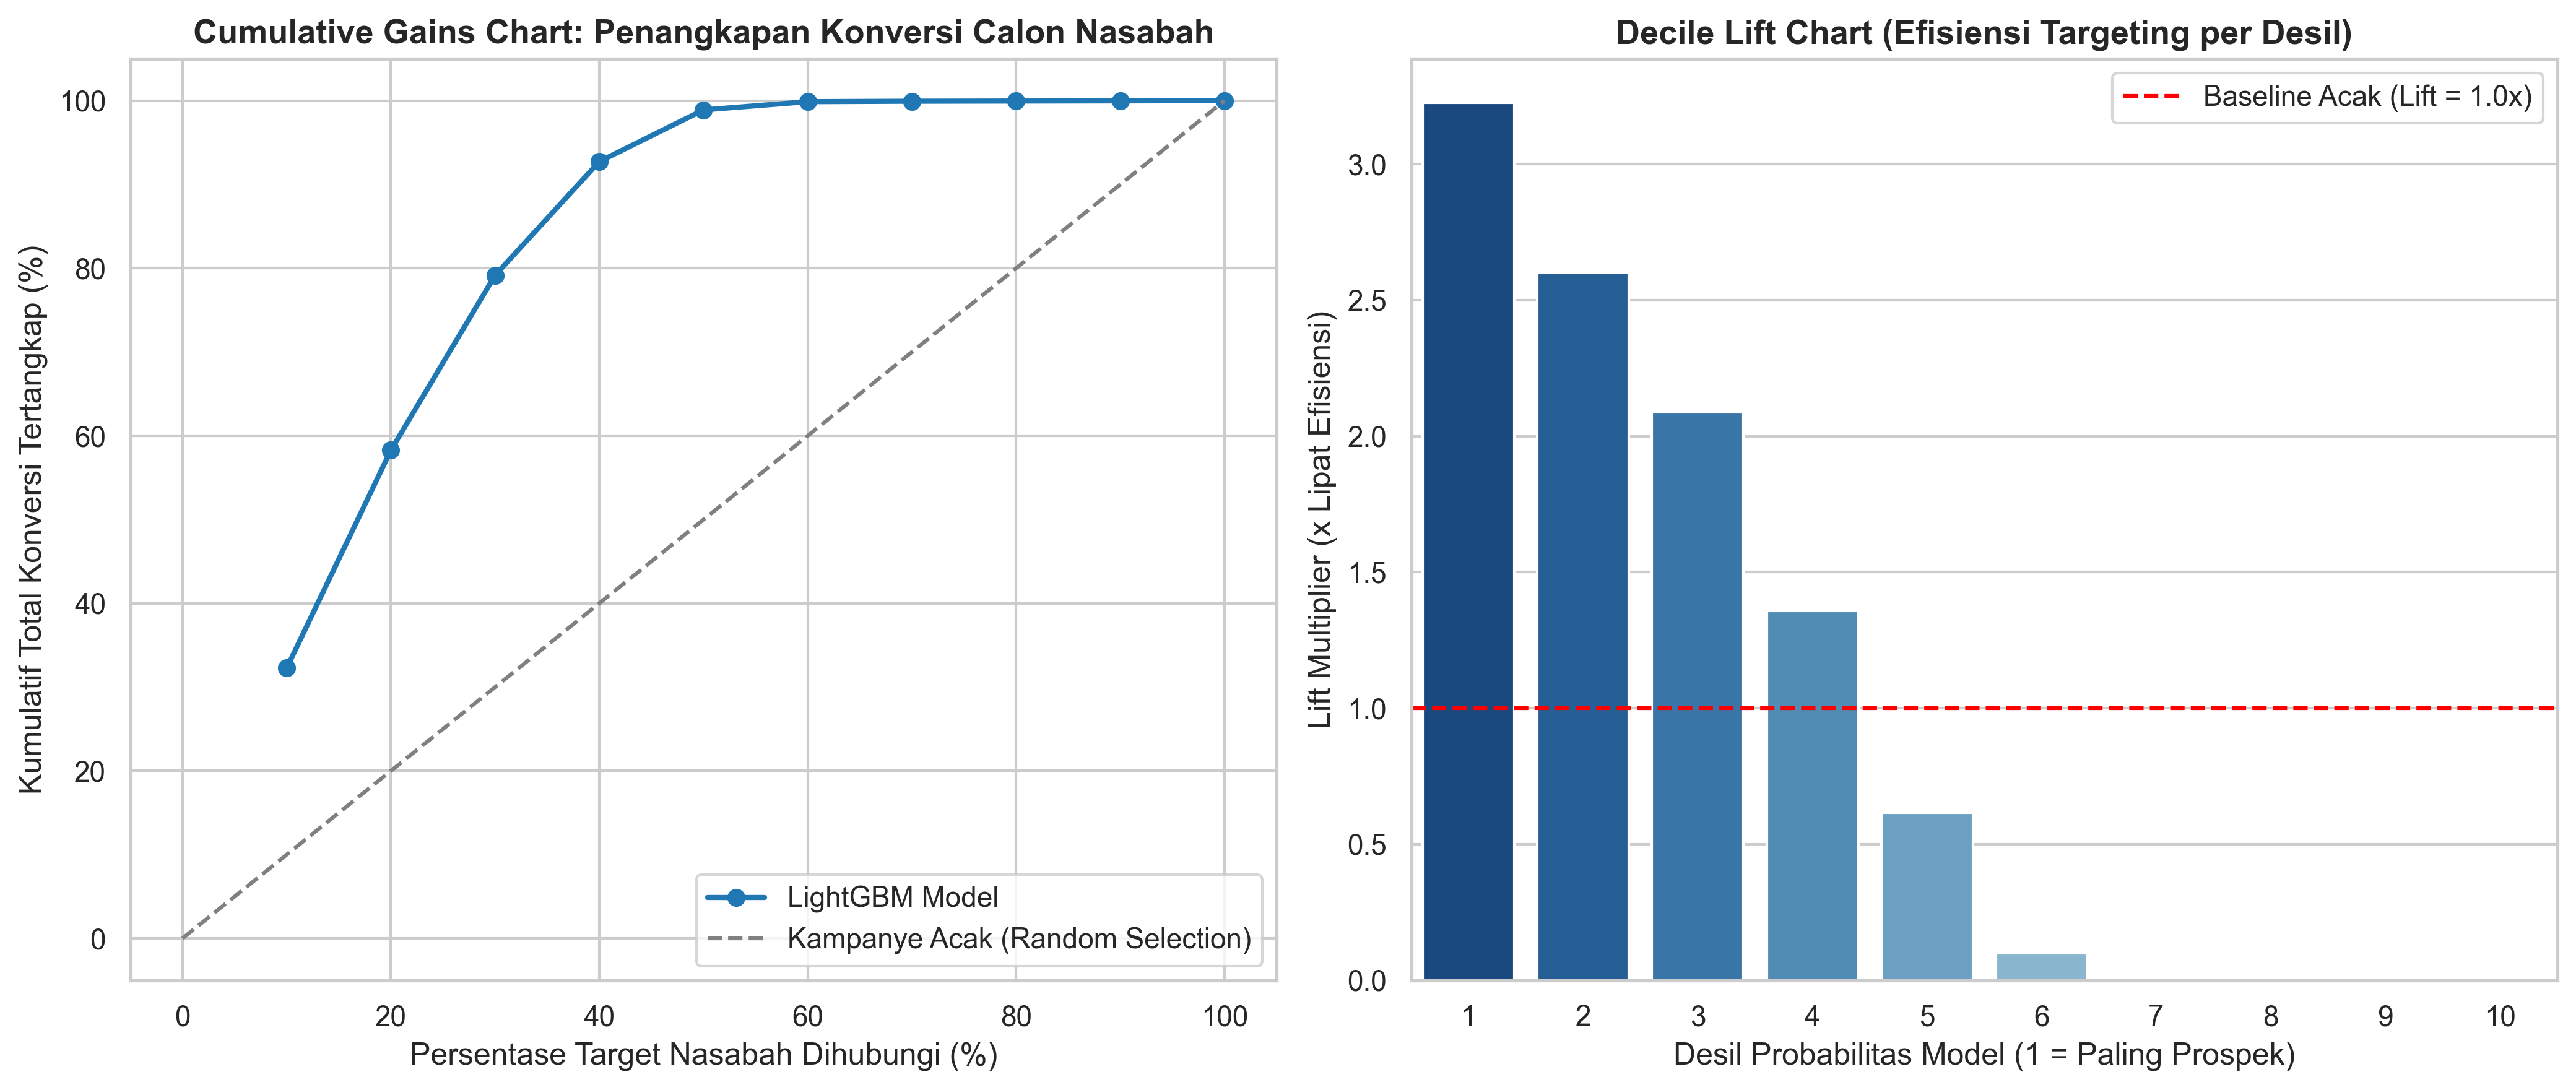

Visualisasi cumulative gains & lift chart berhasil diekspor ke images/cross_sell_gains_lift.png


In [6]:
# Analisis Kampanye Pemasaran: Cumulative Gains & Lift per Decile
def calculate_decile_lift(y_true, y_prob):
    df_eval = pd.DataFrame({'true': y_true, 'prob': y_prob})
    df_eval = df_eval.sort_values('prob', ascending=False).reset_index(drop=True)
    df_eval['decile'] = pd.qcut(df_eval.index, q=10, labels=np.arange(1, 11))
    
    summary = df_eval.groupby('decile', observed=False).agg(
        total_customers=('true', 'count'),
        conversions=('true', 'sum'),
        conversion_rate=('true', 'mean')
    ).reset_index()
    
    total_conv = df_eval['true'].sum()
    summary['cum_conversions'] = summary['conversions'].cumsum()
    summary['cum_gains_pct'] = (summary['cum_conversions'] / total_conv) * 100
    overall_rate = df_eval['true'].mean()
    summary['lift'] = summary['conversion_rate'] / overall_rate
    return summary

lift_table = calculate_decile_lift(y_test, prob_lgb)
print("=== TABEL LIFT KAMPANYE PER DESIL (LIGHTGBM) ===")
print(lift_table[['decile', 'total_customers', 'conversions', 'conversion_rate', 'cum_gains_pct', 'lift']])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Cumulative Gains Chart
axes[0].plot(np.arange(10, 110, 10), lift_table['cum_gains_pct'], marker='o', color='#1f77b4', lw=2, label='LightGBM Model')
axes[0].plot([0, 100], [0, 100], color='gray', linestyle='--', label='Kampanye Acak (Random Selection)')
axes[0].set_title('Cumulative Gains Chart: Penangkapan Konversi Calon Nasabah', fontweight='bold')
axes[0].set_xlabel('Persentase Target Nasabah Dihubungi (%)')
axes[0].set_ylabel('Kumulatif Total Konversi Tertangkap (%)')
axes[0].legend(loc='lower right')

# 2. Lift by Decile
sns.barplot(data=lift_table, x='decile', y='lift', palette='Blues_r', ax=axes[1])
axes[1].axhline(1.0, color='red', linestyle='--', label='Baseline Acak (Lift = 1.0x)')
axes[1].set_title('Decile Lift Chart (Efisiensi Targeting per Desil)', fontweight='bold')
axes[1].set_xlabel('Desil Probabilitas Model (1 = Paling Prospek)')
axes[1].set_ylabel('Lift Multiplier (x Lipat Efisiensi)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('images/cross_sell_gains_lift.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualisasi cumulative gains & lift chart berhasil diekspor ke images/cross_sell_gains_lift.png")